In [3]:
## importing packages ##
import numpy as np
import pandas as pd

import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt
import re
from imp import reload
import pickle

import string
import nltk
from nltk.stem import WordNetLemmatizer 
from nltk.corpus import stopwords,wordnet 
# nltk.download('averaged_perceptron_tagger')
# nltk.download('vader_lexicon')
# nltk.download('wordnet')

from textblob import TextBlob
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import GridSearchCV
from sklearn.decomposition import LatentDirichletAllocation
import pyLDAvis
import pyLDAvis.sklearn
pyLDAvis.enable_notebook()


import warnings
warnings.filterwarnings("ignore")

C:\Users\kavia\AppData\Local\Temp\ipykernel_23904\3653736311.py:10: DeprecationWarning: the imp module is deprecated in favour of importlib; see the module's documentation for alternative uses
  from imp import reload


In [7]:
df = pd.read_csv('../preprocesseddata/2020-01-01_2023-04-10.csv')

In [8]:
df.head()

,Text,Datetime,Word,Make,Model
0,"CarlinKit Tesla Wireless CarPlay Adapter, for ...",2023-04-09 23:32:34+00:00,Tesla,Tesla,not mentioned
1,@user @user @user The only problem is RIVN kee...,2023-04-09 23:26:38+00:00,Tesla,Tesla,not mentioned
2,"Model X Long Range Demo\nKing Of Prussia, PA\n...",2023-04-09 23:23:56+00:00,Model X,Tesla,Model X
3,1074812-00-B New Set of (4) TPMS Tire Pressure...,2023-04-09 23:18:28+00:00,Tesla,Tesla,not mentioned
4,"Model X Long Range New\nBuena Park, CA\nPearl ...",2023-04-09 23:17:51+00:00,Model X,Tesla,Model X


The shape of the tfidf is (119945, 29720), meaning that there are 119945 Text and 29720 tokens made through the filtering process.
Best Model's Params:  {'learning_decay': 0.5, 'n_components': 5}
Model Log Likelihood Score:  -1140737.9967214349
Model Perplexity:  10255.424842969198


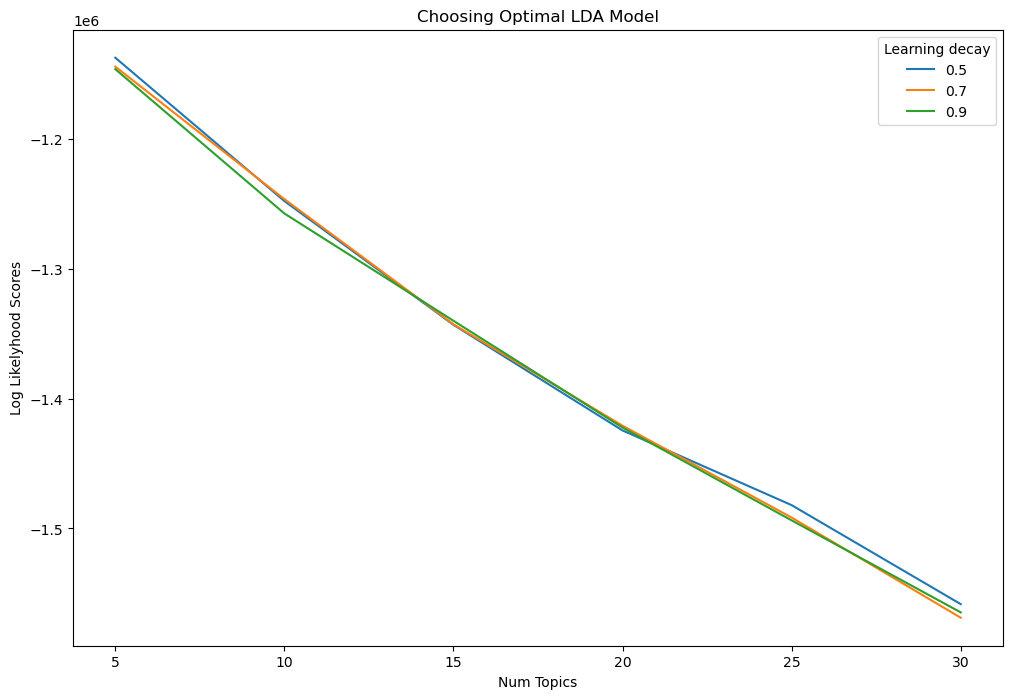

In [12]:
# from https://medium.com/swlh/sentiment-analysis-topic-modeling-for-hotel-reviews-6b83653f5b08

#Create a function to build the optimal LDA model
def optimal_lda_model(df_tweets, tweets_colname):
    '''
    INPUTS:
        df_review - dataframe that contains the tweets
        review_colname: name of column that contains tweets
        
    OUTPUTS:
        lda_tfidf - Latent Dirichlet Allocation (LDA) model
        dtm_tfidf - document-term matrix in the tfidf format
        tfidf_vectorizer - word frequency in the tweets
        A graph comparing LDA Model Performance Scores with different params
    '''
    docs_raw = df_tweets[tweets_colname].tolist()

    #************   Step 1: Convert to document-term matrix   ************#

    # Transform text to vector form using the vectorizer object
    tf_vectorizer = CountVectorizer(stop_words = 'english',
                                    lowercase = True,
                                    ngram_range=(1, 2),
                                    # token_pattern = r'\b[a-zA-Z]{3,}\b', # num chars > 3 to avoid some meaningless words
                                    min_df = 10)                         # discard words that appear in < 10 reviews    

    #apply transformation
    tfidf_vectorizer = TfidfVectorizer(**tf_vectorizer.get_params())

    #convert to document-term matrix
    dtm_tfidf = tfidf_vectorizer.fit_transform(docs_raw)  

    print(f"The shape of the tfidf is {dtm_tfidf.shape}, meaning that there are {dtm_tfidf.shape[0]} {tweets_colname} and {dtm_tfidf.shape[1]} tokens made through the filtering process.")



    #*******   Step 2: GridSearch & parameter tuning to find the optimal LDA model   *******#

    # Define Search Param
    search_params = {'n_components': [5, 10, 15, 20, 25, 30], 
                     'learning_decay': [.5, .7, .9]}

    # Init the Model
    lda = LatentDirichletAllocation()

    # Init Grid Search Class
    model = GridSearchCV(lda, param_grid=search_params)

    # Do the Grid Search
    model.fit(dtm_tfidf)


    #*****  Step 3: Output the optimal lda model and its parameters  *****#

    # Best Model
    best_lda_model = model.best_estimator_

    # Model Parameters
    print("Best Model's Params: ", model.best_params_)

    # Log Likelihood Score: Higher the better
    print("Model Log Likelihood Score: ", model.best_score_)

    # Perplexity: Lower the better. Perplexity = exp(-1. * log-likelihood per word)
    print("Model Perplexity: ", best_lda_model.perplexity(dtm_tfidf))


    #***********   Step 4: Compare LDA Model Performance Scores   ***********#

    #Get Log Likelyhoods from Grid Search Output
    gscore=model.fit(dtm_tfidf).cv_results_
    n_topics = [5, 10, 15, 20, 25, 30]

    log_likelyhoods_5 = [gscore['mean_test_score'][gscore['params'].index(v)] for v in gscore['params'] if v['learning_decay']==0.5]
    log_likelyhoods_7 = [gscore['mean_test_score'][gscore['params'].index(v)] for v in gscore['params'] if v['learning_decay']==0.7]
    log_likelyhoods_9 = [gscore['mean_test_score'][gscore['params'].index(v)] for v in gscore['params'] if v['learning_decay']==0.9]

    # Show graph
    plt.figure(figsize=(12, 8))
    plt.plot(n_topics, log_likelyhoods_5, label='0.5')
    plt.plot(n_topics, log_likelyhoods_7, label='0.7')
    plt.plot(n_topics, log_likelyhoods_9, label='0.9')
    plt.title("Choosing Optimal LDA Model")
    plt.xlabel("Num Topics")
    plt.ylabel("Log Likelyhood Scores")
    plt.legend(title='Learning decay', loc='best')
    plt.show()

    return best_lda_model, dtm_tfidf, tfidf_vectorizer

best_lda_model, dtm_tfidf, tfidf_vectorizer = optimal_lda_model(df, 'Text')

In [25]:
#Create a function to inspect the topics we created 
def display_topics(model, feature_names, n_top_words):
    '''
    INPUTS:
        model - the model we created
        feature_names - tells us what word each column in the matric represents
        n_top_words - number of top words to display
    OUTPUTS:
        a dataframe that contains the topics we created and the weights of each token
    '''
    topic_dict = {}
    for topic_idx, topic in enumerate(model.components_):
        topic_dict[f"Topic {topic_idx+1} words"] = [feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]
        topic_dict[f"Topic {topic_idx+1} weights"] = [f'{topic[i]:.1f}' for i in topic.argsort()[:-n_top_words - 1:-1]]

    return pd.DataFrame(topic_dict)


display_topics(best_lda_model, tfidf_vectorizer.get_feature_names(), n_top_words = 20) 

,Topic 1 words,Topic 1 weights,Topic 2 words,Topic 2 weights,Topic 3 words,Topic 3 weights,Topic 4 words,Topic 4 weights,Topic 5 words,Topic 5 weights
0,electric,1753.9,model,1154.1,user,6325.1,http,742.9,interior,581.7
1,http,1252.7,http,902.3,user user,4311.1,tesla,509.4,http,461.5
2,mercedes,1193.0,tesla,889.3,model,3380.6,tesla model,407.9,model,455.7
3,eqs,954.7,model model,683.3,tesla,2638.7,model,384.0,black,403.6
4,audi,917.6,tesla model,625.2,tesla model,1884.6,ebay,323.2,model long,379.6
5,bmw,864.6,days,379.8,car,903.9,http ebay,316.2,long range,353.7
6,benz,714.3,tsla,339.2,user model,901.5,electricvehicles,304.9,seat,352.8
7,mercedes benz,692.2,buy tesla,336.6,like,864.4,vw,281.8,tesla,340.6
8,tron,634.0,days left,335.6,user tesla,831.4,ebay http,278.3,wheels,332.9
9,suv,569.9,left buy,334.3,just,817.7,https,265.2,long,327.9


In [26]:
# Topic Modelling Visualization for the Negative Reviews
pyLDAvis.sklearn.prepare(best_lda_model, dtm_tfidf, tfidf_vectorizer)

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
2      0.073540 -0.093999       1        1  42.044875
0      0.164641  0.209429       2        1  19.244979
1     -0.011227 -0.160882       3        1  13.778571
4     -0.287454  0.092322       4        1  12.473732
3      0.060501 -0.046871       5        1  12.457844, topic_info=            Term         Freq        Total Category  logprob  loglift
28057  user user  3782.000000  3782.000000  Default  30.0000  30.0000
8818    electric  2318.000000  2318.000000  Default  29.0000  29.0000
27380       user  6002.000000  6002.000000  Default  28.0000  28.0000
15797   mercedes  1300.000000  1300.000000  Default  27.0000  27.0000
9493         eqs   916.000000   916.000000  Default  26.0000  26.0000
...          ...          ...          ...      ...      ...      ...
12635      https   280.416798  1396.414353   Topic5  -5.4168   0.4774
5435        cars   243.907506  1095.546792   Topic5  -5.5563   0.5806
9184    elonmusk   214.857751   405.050267   Topic5  -5.6831   1.4488
4242         bmw   234.926642  1352.575980   Topic5  -5.5938   0.3323
8818    electric   233.809060  2318.674146   Topic5  -5.5986  -0.2114

[335 rows x 6 columns], token_table=       Topic      Freq   Term
term                         
7          1  0.175395    000
7          2  0.076317    000
7          3  0.333385    000
7          4  0.377569    000
7          5  0.037489    000
...      ...       ...    ...
29583      4  0.085712  years
29583      5  0.030251  years
29625      1  0.976257    yes
29625      2  0.018079    yes
29625      5  0.006026    yes

[620 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[3, 1, 2, 5, 4])

In [ ]:
with open('topic_modeling.pickle', 'wb') as f:
    pickle.dump((best_lda_model, dtm_tfidf, tfidf_vectorizer), f)